# DNV-RP-F101 isolated metal-loss pressure screening

This example uses NeqSim's edition-aware `DnvRpF101CorrodedPipelineScreeningKernel` for the current `2019-09+AMD:2025-09` basis. Its narrow scope is one verified isolated longitudinal metal-loss defect under internal pressure.

> **Boundary:** this is a regression-backed `SCREENING` calculation, not fitness-for-service acceptance. Inspection sizing, growth allowance, material and pressure bases, and the pressure factor are caller-controlled evidence. Interacting or complex defects, combined compression, probabilistic assessment, crack-like damage, repair, and approval remain external. It does not replace any DNV-ST-F101 pipeline-system design check.

In [1]:
from pathlib import Path
import os
import sys
import jpype

ROOT = Path.cwd().resolve()
while not (ROOT / 'pom.xml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'pom.xml').exists(), 'Run this notebook from the NeqSim repository tree'

if not jpype.isJVMStarted():
    local_classpath = os.environ.get('NEQSIM_NOTEBOOK_CLASSPATH')
    if local_classpath:
        jpype.startJVM(classpath=local_classpath.split(os.pathsep), convertStrings=True)
    else:
        sys.path.insert(0, str(ROOT / 'devtools'))
        from neqsim_dev_setup import neqsim_init
        neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False)

from jpype import JClass
import pandas as pd
import matplotlib.pyplot as plt
print('Workspace kernel loaded:', ROOT)

mkdir -p failed for path /root/.config/matplotlib: [Errno 30] Read-only file system: '/root/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-bwdrzosj because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Workspace kernel loaded: /workspace/scratch/de313162ffce/repo_f101_corroded


## 1. Verified demonstration basis

The assessment depth is the measured maximum depth plus a controlled allowance. Outside diameter, assessment wall thickness, characteristic ultimate tensile strength, internal/external absolute pressures, and the project pressure factor must use one consistent approved basis. The verification flags are attestations; the underlying inspection and engineering records remain external.

In [2]:
StandardType = JClass('neqsim.process.mechanicaldesign.designstandards.StandardType')
StandardEdition = JClass('neqsim.process.mechanicaldesign.designstandards.StandardEdition')
Kernel = JClass('neqsim.process.engineering.calculation.DnvRpF101CorrodedPipelineScreeningKernel')
Input = JClass('neqsim.process.engineering.calculation.DnvRpF101CorrodedPipelineScreeningKernel$Input')

edition = StandardEdition.defaultEdition(StandardType.DNV_RP_F101)
kernel = Kernel()

def run_defect(depth_m=0.004, length_m=0.2, inspection_verified=True):
    defect_input = (Input.builder(edition, 'Pipeline')
        .steelOuterDiameterM(0.508)
        .assessmentWallThicknessM(0.0127)
        .measuredDefectDepthM(depth_m)
        .defectDepthAllowanceM(0.0005)
        .defectAxialLengthM(length_m)
        .characteristicUltimateTensileStrengthPa(535.0e6)
        .internalPressurePaAbsolute(10.1e6)
        .externalPressurePaAbsolute(0.1e6)
        .callerControlledPressureFactor(0.72)
        .geometryVerified(True)
        .inspectionSizingVerified(inspection_verified)
        .materialStrengthVerified(True)
        .pressureBasisVerified(True)
        .projectFactorVerified(True)
        .isolatedLongitudinalMetalLossApplicabilityVerified(True)
        .build())
    return kernel.calculate(defect_input, None)

result = run_defect()
assessment = result.getValue()
summary = pd.Series({
    'status': str(result.getStatus()),
    'edition': str(assessment.getStandardEdition()),
    'scope': str(assessment.toMap().get('scope')),
    'assessment depth [mm]': 1e3 * float(assessment.getAssessmentDefectDepthM()),
    'remaining wall [mm]': 1e3 * float(assessment.getRemainingWallThicknessM()),
    'length correction Q [-]': float(assessment.getLengthCorrectionFactor()),
    'calculated failure pressure [MPa]': 1e-6 * float(assessment.getCalculatedFailurePressurePa()),
    'caller-controlled limit [MPa]': 1e-6 * float(assessment.getCallerControlledPressureLimitPa()),
    'pressure utilization [-]': float(assessment.getPressureUtilization()),
    'within caller-controlled limit': bool(assessment.isWithinCallerControlledPressureLimit()),
    'engineering approval required': bool(assessment.toMap().get('engineeringApprovalRequired')),
})
assert str(result.getStatus()) == 'CALCULATED_REVIEW_REQUIRED'
assert abs(float(assessment.getCalculatedFailurePressurePa()) - 22346646.7258146) < 1e-8
assert abs(float(assessment.getPressureUtilization()) - 0.6215200454591963) < 1e-12
summary.to_frame('screening result')

,screening result
status,CALCULATED_REVIEW_REQUIRED
edition,DNV-RP-F101 2019-09+AMD:2025-09
scope,ISOLATED_LONGITUDINAL_METAL_LOSS_INTERNAL_PRES...
assessment depth [mm],4.5
remaining wall [mm],8.2
length correction Q [-],1.709387
calculated failure pressure [MPa],22.346647
caller-controlled limit [MPa],16.089586
pressure utilization [-],0.62152
within caller-controlled limit,True


## 2. Defect-geometry sensitivity

The sweep holds every other input fixed and varies measured depth and axial length. It illustrates only the implemented isolated-defect equation. It is not an interaction rule, inspection-uncertainty model, corrosion-growth forecast, allowable-defect chart, or repair decision.

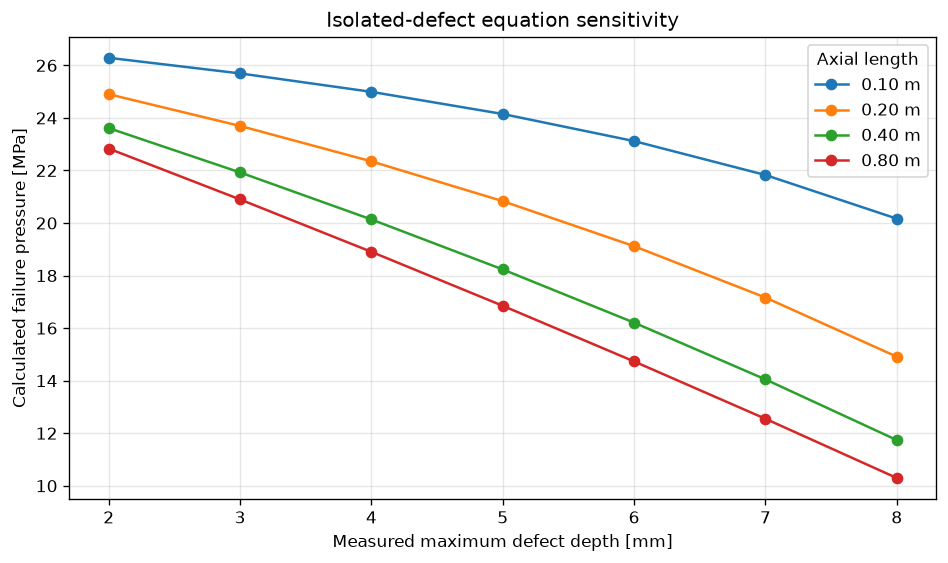

In [3]:
depths_mm = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
lengths_m = [0.10, 0.20, 0.40, 0.80]
rows = []
for length_m in lengths_m:
    for depth_mm in depths_mm:
        sweep_result = run_defect(depth_m=depth_mm / 1000.0, length_m=length_m)
        sweep_value = sweep_result.getValue()
        rows.append({
            'measured depth [mm]': depth_mm,
            'axial length [m]': length_m,
            'failure pressure [MPa]': 1e-6 * float(sweep_value.getCalculatedFailurePressurePa()),
            'pressure utilization [-]': float(sweep_value.getPressureUtilization()),
        })
sensitivity = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.8))
for length_m, group in sensitivity.groupby('axial length [m]'):
    ax.plot(group['measured depth [mm]'], group['failure pressure [MPa]'], marker='o', label=f'{length_m:.2f} m')
ax.set_xlabel('Measured maximum defect depth [mm]')
ax.set_ylabel('Calculated failure pressure [MPa]')
ax.set_title('Isolated-defect equation sensitivity')
ax.grid(True, alpha=0.3)
ax.legend(title='Axial length')
fig.tight_layout()
assert sensitivity.groupby('axial length [m]')['failure pressure [MPa]'].apply(lambda values: values.is_monotonic_decreasing).all()
plt.show()

## 3. Fail closed when inspection evidence is missing

A numeric depth does not establish a defensible inspection basis. The same dimensions are therefore blocked when the inspection-sizing attestation is false. In a project workflow, retain the inspection method, sizing uncertainty, growth allowance, feature classification, and approval records beside the calculation.

In [4]:
blocked = run_defect(inspection_verified=False)
findings = pd.DataFrame([{
    'code': str(item.toMap().get('code')),
    'severity': 'BLOCKER',
    'message': str(item.toMap().get('message')),
} for item in blocked.getReadiness().getBlockers()])
assert str(blocked.getStatus()) == 'BLOCKED'
assert blocked.getValue() is None
assert 'RP_F101_INSPECTION_NOT_VERIFIED' in set(findings['code'])
findings

,code,severity,message
0,RP_F101_INSPECTION_NOT_VERIFIED,BLOCKER,Defect sizing and depth allowance have not bee...
